The detailed Perceptron mechanisms see in assignment 2 this course and assignment we're going to use existing frameworks to impliment the perceptron and feedforward neural networks.

sklearn and iris dataset--the small and classic dataset for machine learning, shows the basic of the a dataset has--features, labels and samples

In [18]:
from sklearn.datasets import load_iris
iris=load_iris()
print(iris.data.shape)
iris

(150, 4)


{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [19]:
import pandas as pd
# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
df['target'] = iris.target

# Display the first few rows
print(df) # df.head() / df.tail()

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target  
0         0  

Example of using sklearn

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Accuracy: 1.0


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


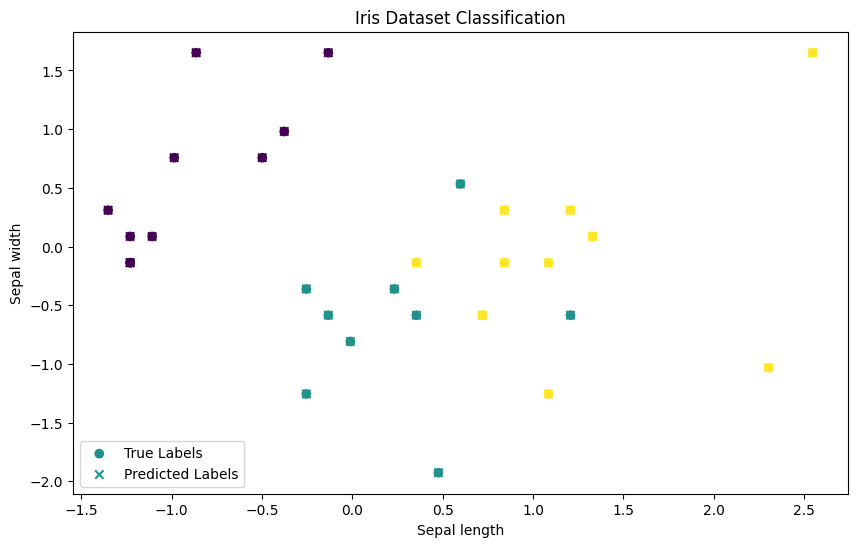

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (important for neural networks)
scaler = StandardScaler() # MinMaxScaler() (Normalization)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build and train the neural network
mlp = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', solver='adam', max_iter=500, random_state=42) # MLPClassifier(hidden_layer_sizes=(10, 20,10) 3 hidden layers and their neuron numbers
# loss cross entropy for classifier and MSE for MLPRegressor
mlp.fit(X_train, y_train)

# Make predictions
y_pred = mlp.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# Plot some of the test results
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='o', label='True Labels')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, marker='x', label='Predicted Labels')
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.title('Iris Dataset Classification')
plt.legend()
plt.show()


Cross-entropy loss is a common loss function used in classification tasks, especially in neural networks. It measures the difference between two probability distributions: the predicted probabilities (output by the model) and the true distribution (ground truth labels). The goal of training is to minimize this loss, which corresponds to making the predicted probabilities as close as possible to the true distribution.

(For binary classification)Binary Cross-Entropy Loss = (-1/n)∑[y_i.log(p_i)+(1-y_i).log(1-p_i)]
Where

n: Number of samples.

y_i: True label for sample i (0 or 1).

p_i: Predicted probability for sample i (between 0 and 1).

(For multi-class classification)Categorical Cross-Entropy Loss = (-1/n)∑∑y_i_c.log(p_i_c)

Where:

n: Number of samples.
c: Number of classes.
y_i_c: True label for sample i and class c (one-hot encoded: 1 if the sample belongs to class c, otherwise 0).
p_i_c: Predicted probability for sample i and class c.

Why Use Cross-Entropy?

It penalizes incorrect predictions more heavily when the predicted probability is far from the true label.

It works well with softmax activation in the output layer, which converts raw scores (logits) into probabilities.

Step 1: Binary Cross-Entropy (From Scratch)

In [21]:
import numpy as np

def binary_cross_entropy_loss(y_true, y_pred):
    """
    Compute binary cross-entropy loss manually.

    Parameters:
        y_true (numpy array): True labels (0 or 1), shape (N,).
        y_pred (numpy array): Predicted probabilities (between 0 and 1), shape (N,).

    Returns:
        float: Mean binary cross-entropy loss.
    """
    epsilon = 1e-7  # Small value to avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Clip values to prevent numerical instability
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# Example Usage
y_true = np.array([1, 0, 1, 1, 0])  # True labels
y_pred = np.array([0.9, 0.1, 0.8, 0.7, 0.2])  # Predicted probabilities

loss = binary_cross_entropy_loss(y_true, y_pred)
print(f"Manually Calculated Binary Cross-Entropy Loss: {loss:.4f}")

Manually Calculated Binary Cross-Entropy Loss: 0.2027


Step 2: Categorical Cross-Entropy (From Scratch)

In [22]:
def categorical_cross_entropy_loss(y_true, y_pred):
    """
    Compute categorical cross-entropy loss manually.

    Parameters:
        y_true (numpy array): True labels (one-hot encoded), shape (N, C).
        y_pred (numpy array): Predicted probabilities, shape (N, C).

    Returns:
        float: Mean categorical cross-entropy loss.
    """
    epsilon = 1e-7  # Small value to avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)  # Clip values to prevent numerical instability
    loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))  # Sum over classes, then mean over samples
    return loss

# Example Usage
y_true = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])  # One-hot encoded true labels
y_pred = np.array([[0.8, 0.1, 0.1], [0.2, 0.7, 0.1], [0.1, 0.2, 0.7]])  # Predicted probabilities

loss = categorical_cross_entropy_loss(y_true, y_pred)
print(f"Manually Calculated Categorical Cross-Entropy Loss: {loss:.4f}")

Manually Calculated Categorical Cross-Entropy Loss: 0.3122


Step 3: Comparison with PyTorch's Built-In Loss Functions

In [23]:
import torch
import torch.nn as nn

# Binary Cross-Entropy Loss in PyTorch
bce_loss_fn = nn.BCELoss()  # Binary Cross-Entropy Loss
y_true_tensor = torch.tensor([1.0, 0.0, 1.0, 1.0, 0.0])  # True labels
y_pred_tensor = torch.tensor([0.9, 0.1, 0.8, 0.7, 0.2])  # Predicted probabilities
bce_loss = bce_loss_fn(y_pred_tensor, y_true_tensor)
print(f"PyTorch Binary Cross-Entropy Loss: {bce_loss.item():.4f}")

# Categorical Cross-Entropy Loss in PyTorch
cce_loss_fn = nn.CrossEntropyLoss()  # Categorical Cross-Entropy Loss
y_true_tensor = torch.tensor([0, 1, 2])  # Class indices (not one-hot encoded)
y_pred_tensor = torch.tensor([[2.0, -1.0, -1.0], [-1.0, 2.0, -1.0], [-1.0, -1.0, 2.0]])  # Raw logits
cce_loss = cce_loss_fn(y_pred_tensor, y_true_tensor)
print(f"PyTorch Categorical Cross-Entropy Loss: {cce_loss.item():.4f}")

PyTorch Binary Cross-Entropy Loss: 0.2027
PyTorch Categorical Cross-Entropy Loss: 0.0949


The gradient of the loss with respect to the weights w is:

∂w/∂L = (1/N)∑(p_i−y_i)⋅x_i

Where:

p_i-y_i: Difference between predicted probabilities and true labels.

Gradient Descent Update Rule:

w:=w-η⋅∂L/∂w

where:

η: Learning rate.

Adam Optimizer Update Rule:

Adam combines momentum and adaptive learning rates. The update rules are:

1 Compute the first moment (mean of gradients):

m_t= β1⋅m_(t-1)+(1-β1)⋅g_t

2 Compute the second moment (uncentered variance of gradients):

v_t=β2⋅v_(t-1)+(1-β2)⋅(g_t)^2

3 Bias correction:

M_t=m_t/(1-β1_t)

V_t=v_t/(1-β2_t)​

Update the weights:

w:=w-η⋅M_t/((√V_t)+ϵ)

Where:

g_t: Gradient at time step t.

β1,β2: Exponential decay rates for the first and second moments (default: 0.9, 0.999).

ϵ: Small constant to prevent division by zero (default: 1e-8).

Binary Cross-Entropy Loss with Gradient Descent:

In [24]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-7
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

def gradient_descent_binary(X, y, learning_rate=0.01, epochs=100):
    """
    Perform gradient descent for binary classification using binary cross-entropy loss.

    Parameters:
        X (numpy array): Input features, shape (N, D).
        y (numpy array): True labels (0 or 1), shape (N,).
        learning_rate (float): Learning rate.
        epochs (int): Number of iterations.

    Returns:
        weights (numpy array): Learned weights.
        losses (list): Loss values over epochs.
    """
    N, D = X.shape
    weights = np.zeros(D)  # Initialize weights to zero
    losses = []

    for epoch in range(epochs):
        # Forward pass
        z = np.dot(X, weights)
        y_pred = sigmoid(z)

        # Compute loss
        loss = binary_cross_entropy_loss(y, y_pred)
        losses.append(loss)

        # Compute gradients
        gradients = (1 / N) * np.dot(X.T, (y_pred - y))

        # Update weights
        weights -= learning_rate * gradients

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return weights, losses

# Example Usage
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])  # Input features
y = np.array([0, 0, 1, 1])  # True labels
weights, losses = gradient_descent_binary(X, y, learning_rate=0.1, epochs=100)

Epoch 0, Loss: 0.6931
Epoch 10, Loss: 0.6348
Epoch 20, Loss: 0.6246
Epoch 30, Loss: 0.6146
Epoch 40, Loss: 0.6049
Epoch 50, Loss: 0.5955
Epoch 60, Loss: 0.5863
Epoch 70, Loss: 0.5774
Epoch 80, Loss: 0.5688
Epoch 90, Loss: 0.5604


Categorical Cross-Entropy Loss with Adam Optimizer

In [25]:
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Numerical stability
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def categorical_cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-7
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
    return loss

def adam_optimizer_categorical(X, y, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8, epochs=100):
    """
    Perform Adam optimization for multi-class classification using categorical cross-entropy loss.

    Parameters:
        X (numpy array): Input features, shape (N, D).
        y (numpy array): One-hot encoded true labels, shape (N, C).
        learning_rate (float): Learning rate.
        beta1, beta2 (float): Exponential decay rates for Adam.
        epsilon (float): Small constant to prevent division by zero.
        epochs (int): Number of iterations.

    Returns:
        weights (numpy array): Learned weights.
        losses (list): Loss values over epochs.
    """
    N, D = X.shape
    _, C = y.shape
    weights = np.zeros((D, C))  # Initialize weights to zero
    m = np.zeros_like(weights)  # First moment vector
    v = np.zeros_like(weights)  # Second moment vector
    losses = []

    for epoch in range(epochs):
        # Forward pass
        z = np.dot(X, weights)
        y_pred = softmax(z)

        # Compute loss
        loss = categorical_cross_entropy_loss(y, y_pred)
        losses.append(loss)

        # Compute gradients
        gradients = (1 / N) * np.dot(X.T, (y_pred - y))

        # Update first and second moments
        m = beta1 * m + (1 - beta1) * gradients
        v = beta2 * v + (1 - beta2) * gradients**2

        # Bias correction
        m_hat = m / (1 - beta1**(epoch + 1))
        v_hat = v / (1 - beta2**(epoch + 1))

        # Update weights
        weights -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return weights, losses

# Example Usage
X = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])  # Input features
y = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 0, 0]])  # One-hot encoded true labels
weights, losses = adam_optimizer_categorical(X, y, learning_rate=0.01, epochs=100)

Epoch 0, Loss: 1.0986
Epoch 10, Loss: 1.0432
Epoch 20, Loss: 1.0402
Epoch 30, Loss: 1.0369
Epoch 40, Loss: 1.0335
Epoch 50, Loss: 1.0313
Epoch 60, Loss: 1.0288
Epoch 70, Loss: 1.0263
Epoch 80, Loss: 1.0239
Epoch 90, Loss: 1.0216


---
# Perceptron & Feedforward Neural Networks on the Iris Dataset


In [26]:
# Dataset Overview
import warnings
from sklearn.datasets import load_iris

warnings.filterwarnings("ignore")

iris = load_iris()
X_all = iris.data
y_all = iris.target

print(f"Samples  : {X_all.shape[0]}")
print(f"Features : {X_all.shape[1]}  →  {iris.feature_names}")
print(f"Classes  : {len(iris.target_names)}  →  {list(iris.target_names)}")


Samples  : 150
Features : 4  →  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes  : 3  →  [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [27]:
# Data Preparation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Binary dataset (classes 0 and 1) — for Perceptron
mask_bin  = y_all < 2
X_bin     = X_all[mask_bin]
y_bin     = y_all[mask_bin]

X_bin_tr, X_bin_te, y_bin_tr, y_bin_te = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42)

scaler_bin = StandardScaler()
X_bin_tr   = scaler_bin.fit_transform(X_bin_tr)
X_bin_te   = scaler_bin.transform(X_bin_te)

# Full 3-class dataset — for Feedforward NN
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr   = scaler.fit_transform(X_tr)
X_te   = scaler.transform(X_te)


In [28]:
# Implementing Of Activation Functions From My First Task
import torch
import numpy as np
import scipy.special
import torch.nn as nn

def gelu_np(x, scale=1.0):
    xs = x * scale
    return 0.5 * xs * (1 + scipy.special.erf(xs / np.sqrt(2)))

def softplus_np(x, beta=1.0):
    return np.log(1 + np.exp(beta * x)) / beta

def silu_np(x, beta=1.0):
    return x / (1 + np.exp(-beta * x))

def gaussian_np(x, mu=0.0, sigma=1.0):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def sinusoid_np(x, omega=1.0, amplitude=1.0):
    return amplitude * np.sin(omega * x)

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.erf(x / 2 ** 0.5))

class Softplus(nn.Module):
    def __init__(self, beta=1.0):
        super().__init__()
        self.beta = beta
    def forward(self, x):
        return torch.log(1 + torch.exp(self.beta * x)) / self.beta

class SiLU(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class GaussianAct(nn.Module):
    def forward(self, x):
        return torch.exp(-0.5 * x ** 2)

class SinusoidAct(nn.Module):
    def forward(self, x):
        return torch.sin(x)


---
## Perceptron


In [29]:
# Sklearn Perceptron (Classes 0 and 1)
from sklearn.metrics import classification_report
from sklearn.linear_model import Perceptron

skl_perc = Perceptron(max_iter=1000, random_state=42)
skl_perc.fit(X_bin_tr, y_bin_tr)

print("Sklearn Perceptron (Classes 0 and 1):")
print(classification_report(y_bin_te, skl_perc.predict(X_bin_te)))


Sklearn Perceptron (Classes 0 and 1):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [30]:
# Keras Perceptron (Classes 0 and 1)
import tensorflow as tf
from sklearn.metrics import classification_report as cr
from tensorflow import keras

tf.random.set_seed(42)

keras_perc = keras.Sequential([
    keras.layers.Dense(1, activation="sigmoid", input_shape=(4,))
])
keras_perc.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
keras_perc.fit(X_bin_tr, y_bin_tr, epochs=200, verbose=0)

y_pred_kp = (keras_perc.predict(X_bin_te, verbose=0).flatten() >= 0.5).astype(int)

print("Keras Perceptron (Classes 0 and 1):")
print(cr(y_bin_te, y_pred_kp))


Keras Perceptron (Classes 0 and 1):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [31]:
# PyTorch Perceptron (Classes 0 and 1)
import torch
import torch.nn as nn
from sklearn.metrics import classification_report as cr

torch.manual_seed(42)

Xbt = torch.tensor(X_bin_tr, dtype=torch.float32)
ybt = torch.tensor(y_bin_tr, dtype=torch.float32).unsqueeze(1)
Xbe = torch.tensor(X_bin_te, dtype=torch.float32)

class TorchPerceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(4, 1)
    def forward(self, x):
        return torch.sigmoid(self.fc(x))

pt_perc = TorchPerceptron()
opt     = torch.optim.Adam(pt_perc.parameters(), lr=0.01)
loss_fn = nn.BCELoss()

for _ in range(300):
    pt_perc.train()
    loss = loss_fn(pt_perc(Xbt), ybt)
    opt.zero_grad(); loss.backward(); opt.step()

pt_perc.eval()
with torch.no_grad():
    y_pred_pt = (pt_perc(Xbe).squeeze() >= 0.5).int().numpy()

print("PyTorch Perceptron (Classes 0 and 1):")
print(cr(y_bin_te, y_pred_pt))


PyTorch Perceptron (Classes 0 and 1):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



---
## Feedforward Neural Network


In [32]:
# Sklearn Feedforward NN (All 3 Classes)
# MLPClassifier supports only a few activations, so I'll test relu, tanh, and logistic activations

from sklearn.metrics import classification_report as cr
from sklearn.neural_network import MLPClassifier

for act in ["relu", "tanh", "logistic"]:
    mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation=act,
                        solver="adam", max_iter=1000, random_state=42)
    mlp.fit(X_tr, y_tr)
    print(f"Sklearn Feedforward NN (Activation: {act}):")
    print(cr(y_te, mlp.predict(X_te)))


Sklearn Feedforward NN (Activation: relu):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Sklearn Feedforward NN (Activation: tanh):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Sklearn Feedforward NN (Activation: logistic):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       

In [33]:
# Keras Feedforward NN (All 3 Classes)
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report as cr
from tensorflow import keras

tf.random.set_seed(42)

def tf_gaussian(x):
    return tf.exp(-0.5 * x ** 2)

def tf_sinusoid(x):
    return tf.sin(x)

activation_configs = [
    ("gelu",                 "gelu",                          "gelu"),
    ("silu (swish)",         "swish",                         "swish"),
    ("softplus",             "softplus",                      "softplus"),
    ("gaussian (custom)",   keras.layers.Lambda(tf_gaussian), keras.layers.Lambda(tf_gaussian)),
    ("sinusoid (custom)",   keras.layers.Lambda(tf_sinusoid), keras.layers.Lambda(tf_sinusoid)),
    ("gelu + silu mixed",   "gelu",                          "swish"),
]

for label, act1, act2 in activation_configs:
    model = keras.Sequential([
        keras.layers.Dense(16, input_shape=(4,)),
        act1 if isinstance(act1, keras.layers.Layer) else keras.layers.Activation(act1),
        keras.layers.Dense(8),
        act2 if isinstance(act2, keras.layers.Layer) else keras.layers.Activation(act2),
        keras.layers.Dense(3, activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    model.fit(X_tr, y_tr, epochs=200, verbose=0)
    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    print(f"Keras Feedforward NN (Activation: {label}):")
    print(cr(y_te, y_pred))


Keras Feedforward NN (Activation: gelu):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Keras Feedforward NN (Activation: silu (swish)):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Keras Feedforward NN (Activation: softplus):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     

In [34]:
# PyTorch Feedforward NN (All 3 Classes)
import torch
import torch.nn as nn
from sklearn.metrics import classification_report as cr

torch.manual_seed(42)

Xtt = torch.tensor(X_tr, dtype=torch.float32)
ytt = torch.tensor(y_tr, dtype=torch.long)
Xte = torch.tensor(X_te, dtype=torch.float32)

activation_map = {
    "GELU()":        (GELU(),        GELU()),
    "SiLU()":        (SiLU(),        SiLU()),
    "Softplus()":    (Softplus(),     Softplus()),
    "Gaussian()":    (GaussianAct(),  GaussianAct()),
    "Sinusoid()":    (SinusoidAct(),  SinusoidAct()),
    "GELU+SiLU":     (GELU(),        SiLU()),
}

def make_net(act1, act2):
    return nn.Sequential(
        nn.Linear(4, 16), act1,
        nn.Linear(16, 8), act2,
        nn.Linear(8, 3)
    )

for name, (act1, act2) in activation_map.items():
    net     = make_net(act1, act2)
    opt     = torch.optim.Adam(net.parameters(), lr=0.01)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(300):
        net.train()
        loss = loss_fn(net(Xtt), ytt)
        opt.zero_grad(); loss.backward(); opt.step()

    net.eval()
    with torch.no_grad():
        y_pred = net(Xte).argmax(dim=1).numpy()

    print(f"PyTorch Feedforward NN (Activation: {name}):")
    print(cr(y_te, y_pred))


PyTorch Feedforward NN (Activation: GELU()):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

PyTorch Feedforward NN (Activation: SiLU()):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

PyTorch Feedforward NN (Activation: Softplus()):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00 

---
# Commentary

Working on this task, I had to connect the activation functions from my first task with real classification pipelines across three different frameworks. The most interesting part was wrapping the NumPy-based functions into PyTorch `nn.Module` subclasses and Keras Lambda layers.

---

### 1) What’s the differences between perceptron and feedforward network?

| | Perceptron | Feedforward NN |
|---|---|---|
| **Architecture** | Single layer: input → output directly | Multiple layers: input → hidden(s) → output |
| **Activation** | Step function | Any differentiable non-linearity per layer |
| **Decision boundary** | Linear only | Non-linear (with enough neurons) |
| **Output** | Binary | Multi-class via Softmax |
| **Learning** | Perceptron rule (no backprop) | Backpropagation through all layers |

In short — a perceptron is a single neuron that can only solve linearly separable problems. A feedforward network stacks multiple such layers, gains the ability to model complex non-linear patterns, and is trained end-to-end with backpropagation.

---

### 2) Sklearn, keras and torch, which one you like the most? Why? And what’s the difference among those 3 libraries?

**My preference is PyTorch.** The explicit training loop forces you to understand exactly what is happening at every step. That level of transparency is invaluable when debugging or experimenting with custom components like the activation functions from Task 1.

| | Sklearn | Keras | PyTorch |
|---|---|---|---|
| **Level** | High-level ML | High-level DL | Low-level DL |
| **Flexibility** | Limited (fixed architectures) | Medium (easy custom layers) | Full control |
| **Ease of use** | Very easy | Easy | More verbose |
| **Best for** | Classical ML pipelines | Fast DL prototyping | Research & custom models |
| **Custom activations** | Not possible | Via Lambda layers | Native `nn.Module` |

---

### 3)  What’s the optimization methods you’ve used in the backpropagation? Explain why you use it, what’s the advantages and disadvantages of the optimizer you’ve used?

All three frameworks used **Adam (Adaptive Moment Estimation)**.

Adam was chosen because it combines the best of two other optimizers — *SGD with momentum* (which smooths the gradient direction) and *RMSProp* (which adapts the learning rate per parameter). It converges reliably without much hyperparameter tuning, which is ideal for a dataset like Iris.

**Advantages:** adaptive learning rate, fast convergence, robust to noisy gradients, minimal tuning needed.  
**Disadvantages:** uses more memory than SGD (two moment vectors per parameter), can occasionally converge to slightly worse minima than carefully tuned SGD on large-scale problems.
